# Итоговая аттестация по программе профессиональной переподготовки "Аналитик Данных"

## Шаг 1: Предобработка и EDA (Исследовательский анализ данных)

In [ ]:
# Загружаем необходимые библиотеки

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

import os


In [ ]:
# Загружаем датасет

med_df_url = 'https://www.kaggle.com/api/v1/datasets/download/mirichoi0218/insurance'
med_df = pd.read_csv(med_df_url, compression = 'zip')

med_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
# Познакомимся со структурой таблицы, типами данных и особенностями числовых признаков

med_df.info()
med_df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


In [ ]:
# Проверим датасет на дубликаты, упорядочим категориальные значения и убедимся, что нет логичских несоответсвий

duplicates = med_df.duplicated().sum() #был обнвружен 1 дубликат; убираем его
med_df = med_df.drop_duplicates().reset_index(drop=True)

category = ['sex', 'smoker', 'region']
for c in category:
        print(med_df[c].value_counts())

wrong_age = (med_df['age'] < 0).sum()
wrong_bmi = (med_df['bmi'] < 0).sum()
wrong_children = (med_df['children'] < 0).sum()
wrong_charges = (med_df['charges'] < 0).sum()

print(f'Duplicates: {duplicates}')
print(f'Mistakes in categories: {wrong_age, wrong_bmi, wrong_charges, wrong_children}')


sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64
Duplicates: 1
Mistakes in categories: (np.int64(0), np.int64(0), np.int64(0), np.int64(0))


## Оценим взаимосвязь числовых признаков



In [ ]:
# Считаем

numeric_colms = ['age', 'bmi', 'children', 'charges']

corr_matrix = med_df[numeric_colms].corr()


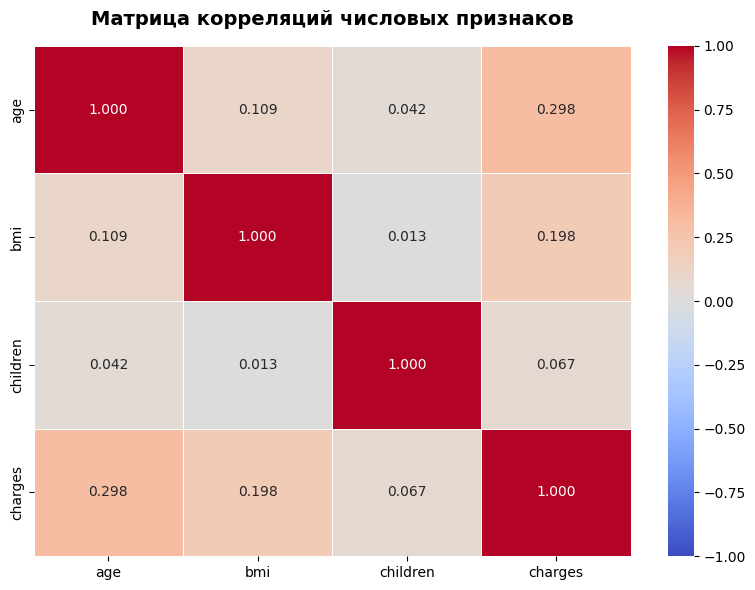

In [ ]:
# Визуализируем

plt.figure(figsize = (8, 6))

sns.heatmap(
    corr_matrix,
    annot = True,
    cmap = 'coolwarm',
    fmt = '.3f',
    linewidths = 0.5,
    vmin = -1, vmax = 1
)

plt.title('Матрица корреляций числовых признаков', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()

plt.show()

## Вывод:
1. Наибольшую корреляцию со стоимостью страховки (charges) имеет признак возраста (age);
2. На втором месте по влиянию находится индекс массы тела (bmi);
3. Наличие у пациента детей (children) практически никак не влияет на стоимость страховки.

## Посмотрим на закономерности между демографическими показателями и расходами пациентов

## 1. Как курение (smoker) влияет на стоимость страховки (charges)?

In [ ]:
# Соберём таблицу

smoking_influence = med_df.groupby('smoker').agg(
        avg_charges = ('charges', 'mean'),
        median_charges = ('charges', 'median'),
        std_charges = ('charges', 'std'),
        count = ('charges', 'count')
).round(2)

smoking_influence['variation_coef'] = (smoking_influence['std_charges'] / smoking_influence['avg_charges'] * 100).round(1)

smoking_influence

,avg_charges,median_charges,std_charges,count,variation_coef
smoker,,,,,
no,8440.66,7345.73,5992.97,1063,71.0
yes,32050.23,34456.35,11541.55,274,36.0


/tmp/ipykernel_1860/3191037067.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


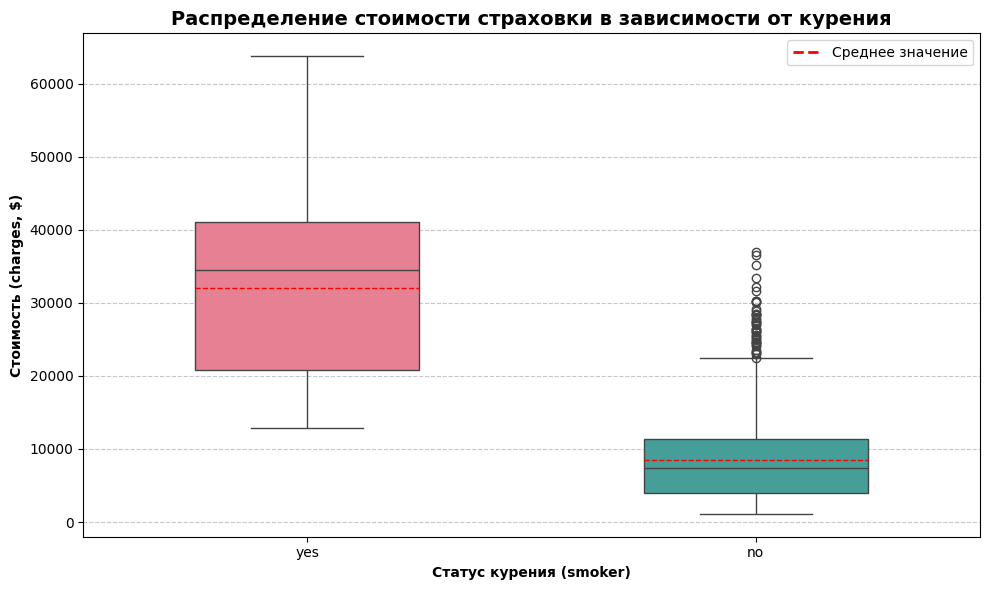

In [ ]:
# Визуализируем

plt.figure(figsize = (10, 6))

sns.boxplot(
    x = 'smoker',
    y = 'charges',
    data = med_df,
    palette = 'husl',
    width = 0.5,
    showmeans = True,
    meanline = True,
    meanprops = {'color': 'red', 'linewidth': 1, 'linestyle': '--'}
)

plt.title('Распределение стоимости страховки в зависимости от курения', fontsize = 14, fontweight = 'bold')
plt.xlabel('Статус курения (smoker)', fontweight = 'bold')
plt.ylabel('Стоимость (charges, $)', fontweight = 'bold')

plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)

legend_elements = [
    Line2D([0], [0], color = 'red', linewidth = 2, linestyle = '--', label = 'Среднее значение')
]

plt.legend(handles=legend_elements, loc = 'upper right')

plt.tight_layout()

plt.show()

## Выводы:

1. Курящие пациенты в среднем платят в 4 раза больше некурящих пациентов (32.000 против 8.000), что соответствует нашим ожиданиям (статья [Weaver&Associates](https://www.weaverinsurance.com/impact-of-smoking-on-life-insurance/));
2. У некурящих пациентов получился очень большой коэффициент вариации, что можно объяснить низкими средними расходами;
3. У курящих пациентов медиана получилась больше среднего, что нетипично. **Гипотеза: среди курящих есть группа с аномально низкими доходами, которая занижает среднее; предположим, что эта группа состоит из молодых людей с нормальным BMI, которые в целом отличаются более крепким здоровьем, благодаря этим характеристикам.**

## Проработаем гипотезу из вывода 3:

In [ ]:
# 1. Отделим курящих и определим порог для пациентов с самыми низкими расходами среди курящих

smokers = med_df[med_df['smoker'] == 'yes']
q1_threshold = smokers['charges'].quantile(0.25)

# 2. Поделим курящих на группы по затратам

low_cost = smokers[smokers['charges'] <= q1_threshold]
high_cost = smokers[smokers['charges'] > q1_threshold]

# 3. Соберём средние значения возраста и BMI для обеих групп в отдельную таблицу

stats = pd.DataFrame({
    'Группа': ['Низкие расходы (нижние 25%)', 'Высокие расходы (верхние 75%)'],
    'Средний возраст': [low_cost['age'].mean(), high_cost['age'].mean()],
    'Средний BMI': [low_cost['bmi'].mean(), high_cost['bmi'].mean()],
    'Средние расходы ($)': [low_cost['charges'].mean(), high_cost['charges'].mean()],
    'Кол-во человек': [len(low_cost), len(high_cost)]
}).round(1)

stats

,Группа,Средний возраст,Средний BMI,Средние расходы ($),Кол-во человек
0,Низкие расходы (нижние 25%),28.2,24.7,17713.7,69
1,Высокие расходы (верхние 75%),42.0,32.7,36875.7,205


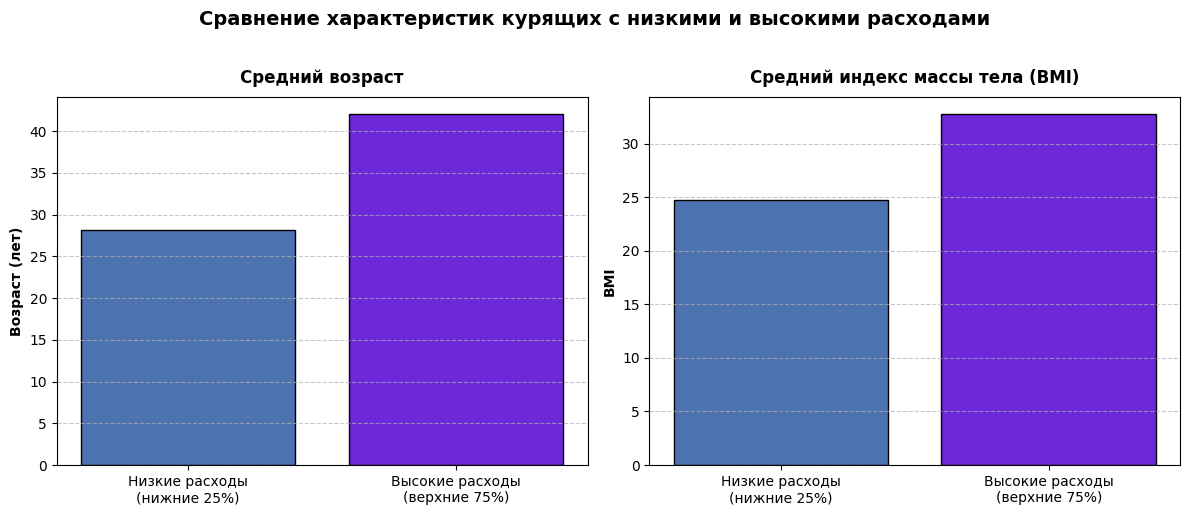

In [ ]:
# Визуализируем

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

groups = ['Низкие расходы\n(нижние 25%)', 'Высокие расходы\n(верхние 75%)']
ages = [low_cost['age'].mean(), high_cost['age'].mean()]
bmis = [low_cost['bmi'].mean(), high_cost['bmi'].mean()]

# График возраста
axes[0].bar(groups, ages, color = ['#4C72B0', '#6D28D9'], edgecolor = 'black')
axes[0].set_title('Средний возраст', fontweight = 'bold', pad = 10)
axes[0].set_ylabel('Возраст (лет)', fontweight = 'bold')
axes[0].grid(axis = 'y', linestyle = '--', alpha = 0.7)

# График BMI
axes[1].bar(groups, bmis, color = ['#4C72B0', '#6D28D9'], edgecolor = 'black')
axes[1].set_title('Средний индекс массы тела (BMI)', fontweight = 'bold', pad =  10)
axes[1].set_ylabel('BMI', fontweight = 'bold')
axes[1].grid(axis = 'y', linestyle ='--', alpha = 0.7)

plt.suptitle('Сравнение характеристик курящих с низкими и высокими расходами',
             fontsize = 14, fontweight = 'bold', y = 1.02)

plt.tight_layout()

plt.show()

## Как мы видим, гипотеза подтвердилась:
Действительно, завышение медианных значений произошло, т.к. среди курящих выделилась группа, где меньше всего страховые платежи у тех пациентов, которые в среднем моложе тех, у которых платежи выше; эти пациенты также, как правило, имеют более здоровую конституцию с индексом массы тела в пределах нормы.

## 2. Как возраст (age) коррелирует со стоимостью (charges)?

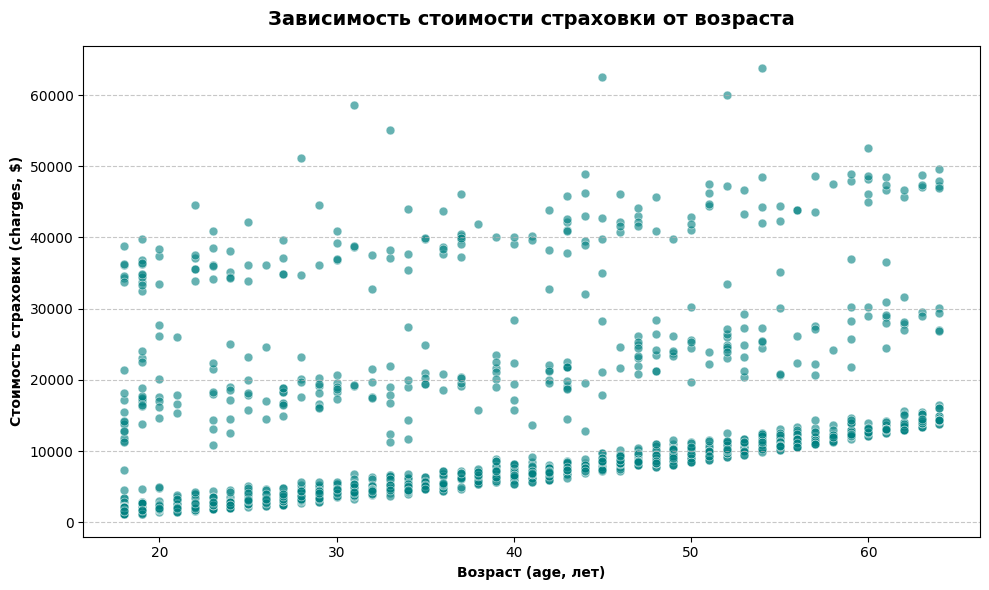

In [ ]:
# Таблица корреляции даёт нам значение 0.298/1.0, то есть зависимость признаков есть, но она небольшая;



# Построим график этой зависимости

plt.figure(figsize = (10, 6))

sns.scatterplot(x = 'age', y = 'charges', data = med_df, alpha = 0.6, s = 40, color = 'teal')

plt.title('Зависимость стоимости страховки от возраста', fontsize = 14, fontweight = 'bold', pad = 15)
plt.xlabel('Возраст (age, лет)', fontweight = 'bold')
plt.ylabel('Стоимость страховки (charges, $)', fontweight = 'bold')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)

plt.tight_layout()

plt.show()

## Выводы:
1. Есть общая тенденция к повышению стоимости страховки с возрастом;
2. Наблюдается разбиение на 3 слоя по стоимости; попробуем проверить, связано ли это с тем, что курильщики с среднем платят за страховку больше, и потому мы наблюдаем две похожих по форме распределения в середине.
3. Нижний слой кажется наиболее густым. **Гипотеза: в среднем, большинство пациентов в нашем датасете имеют относительно небольшие траты по страховке, что также может быть связано с тем, что они не курят и имеют здоровое телосложение, и, следовательно, более здоровы в целом.**

## Проверим, связано ли расслоение с курением и повышеным BMI:

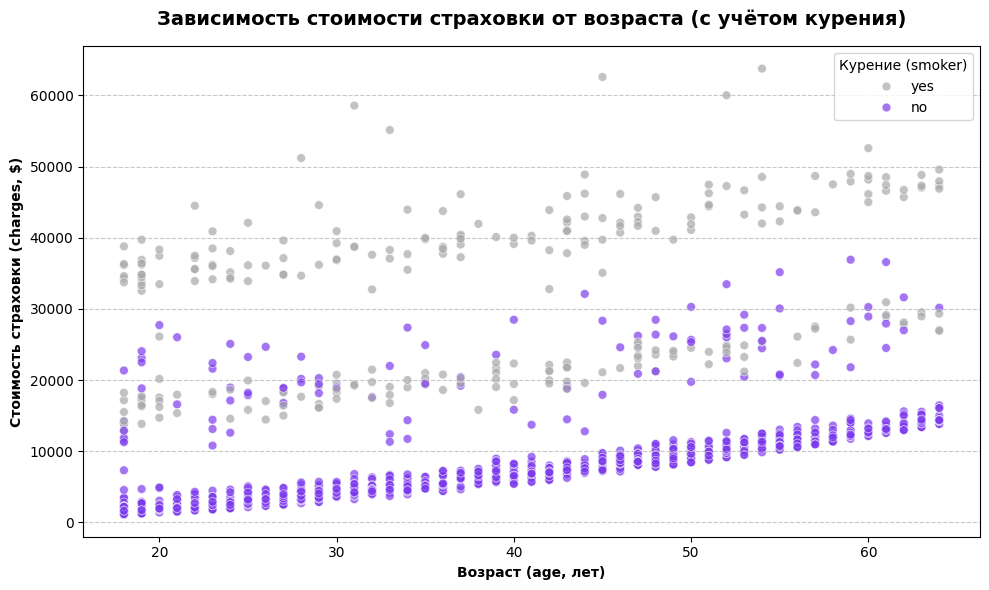

In [ ]:
# Раскрасим точки разным цветом для курящих и не курящих

plt.figure(figsize = (10, 6))

sns.scatterplot(
    x = 'age',
    y = 'charges',
    hue = 'smoker',
    data = med_df,
    alpha = 0.7,
    s = 40,
    palette = ['#A8A9AD', '#7C3AED']
)

plt.title('Зависимость стоимости страховки от возраста (с учётом курения)',
          fontsize = 14, weight = 'bold', pad = 15)

plt.xlabel('Возраст (age, лет)', fontweight = 'bold')
plt.ylabel('Стоимость страховки (charges, $)', fontweight = 'bold')
plt.legend(title = 'Курение (smoker)')

plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)

plt.tight_layout()

plt.show()

In [ ]:
'''
Определяем границы слоёв (примерно, по визуальной оценке графика)
Нижний слой: до 15 000 $
Средний слой: 15 000 – 35 000 $
Верхний слой: выше 35 000 $
'''

lower_layer_num = len(med_df[med_df['charges'] <= 15000])
middle_layer_num = len(med_df[(med_df['charges'] > 15000) & (med_df['charges'] <= 35000)])
upper_layer_num = len(med_df[med_df['charges'] > 35000])


layers_num = pd.DataFrame({
        'Слои':['Нижний слой (до $15000)','Средний слой слой (от $15000 до $35000)', 'Верхний слой (от $35000)'],
        'Кол-во пациентов': [lower_layer_num, middle_layer_num, upper_layer_num]
})


layers_num


,Слои,Кол-во пациентов
0,Нижний слой (до $15000),979
1,Средний слой слой (от $15000 до $35000),225
2,Верхний слой (от $35000),133


In [ ]:
# Посмотрим поближе на то, сколько среди пациентов "нижнего" слоя курильщиков

lower_layer = med_df[med_df['charges'] <= 15000]
middle_layer = med_df[(med_df['charges'] > 15000) & (med_df['charges'] <= 35000)]
upper_layer = med_df[med_df['charges'] > 35000]

smokers_lower = (lower_layer['smoker'] == 'yes').sum()
non_smokers_lower = (lower_layer['smoker'] == 'no').sum()

quant_smokers_lower = pd.DataFrame({
      'Курильщики (взносы до $15000)': [smokers_lower],
      'Некурящие (взносы до $15000)': [non_smokers_lower]
})

quant_smokers_lower

,Курильщики (взносы до $15000),Некурящие (взносы до $15000)
0,7,972


## Выводы:

Действительно, в самом нижнем слое количество пациентов значительно превышает их количество в среднем и верхнем слоях, подтверждая гипотезу о том, что в среднем большинство пациентов всех возрастов тратят на страховку до $15.000.

Мы также можем видеть, что среди пациентов, платящмх до $15.000 большинство являются некурящими.

## 3. Влияют ли индекс массы тела (bmi) и пол (sex) на стоимость (charges)?

In [ ]:
# Таблица корреляции показывает зависимость стоимости (charges) от индекса массы тела (bmi) как 0.198/1.0


# Сооберём таблицу по полу

sex_stats = med_df.groupby('sex').agg(
    avg_charges = ('charges', 'mean'),
    median_charges = ('charges', 'median'),
    avg_bmi = ('bmi', 'mean'),
    avg_age = ('age', 'mean'),
    count = ('charges', 'count')
).round(2)

sex_stats

,avg_charges,median_charges,avg_bmi,avg_age,count
sex,,,,,
female,12569.58,9412.96,30.38,39.50,662
male,13975.00,9377.90,30.94,38.95,675


/tmp/ipykernel_1860/2028956151.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


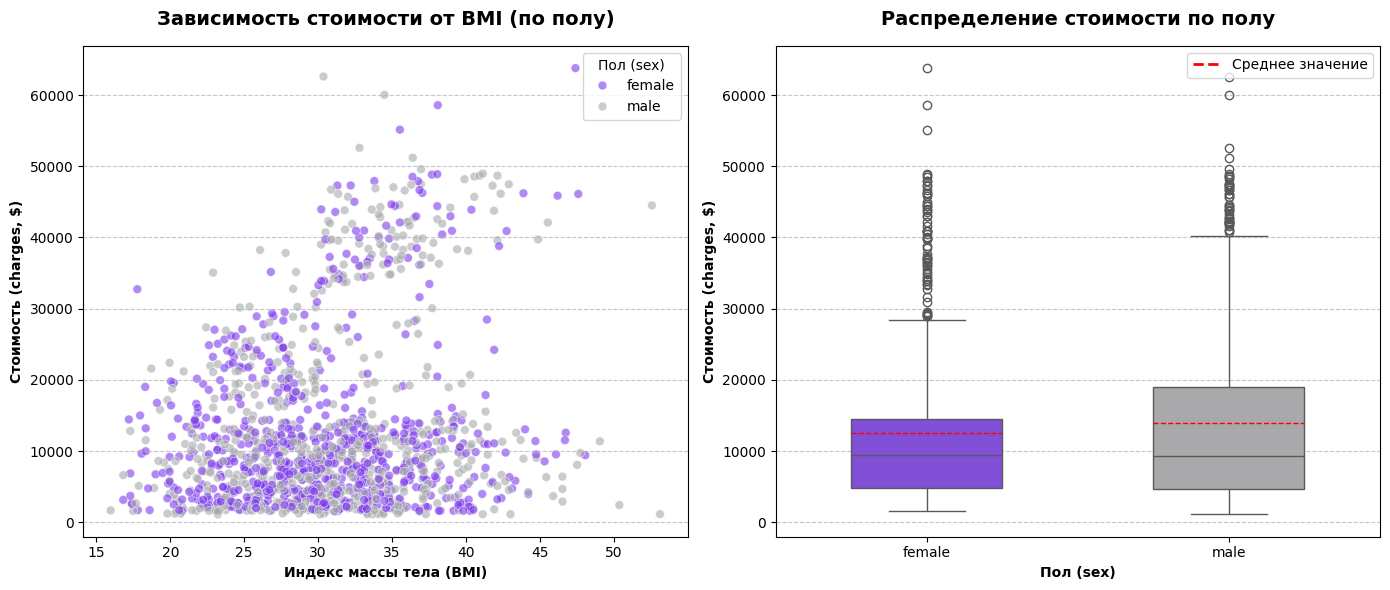

In [ ]:
# Визуализируем

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: BMI vs Стоимость с разделением по полу

sns.scatterplot(
    x = 'bmi',
    y = 'charges',
    hue ='sex',
    data = med_df,
    alpha = 0.6,
    s = 40,
    palette = {'female': '#7C3AED', 'male': '#A8A9AD'},
    ax = axes[0]
)

axes[0].set_title('Зависимость стоимости от BMI (по полу)', fontsize =14, fontweight = 'bold', pad = 15)
axes[0].set_xlabel('Индекс массы тела (BMI)', fontweight = 'bold')
axes[0].set_ylabel('Стоимость (charges, $)', fontweight = 'bold')
axes[0].legend(title = 'Пол (sex)')

axes[0].grid(axis = 'y', linestyle = '--', alpha = 0.7)

# График 2: Зависимость стоимости от пола пациента

sns.boxplot(
    x = 'sex',
    y = 'charges',
    data = med_df,
    palette = {'female': '#7C3AED', 'male': '#A8A9AD'},
    width = 0.5,
    ax = axes[1],
    showmeans = True,
    meanline = True,
    meanprops = {'color': 'red', 'linewidth': 1, 'linestyle': '--'}
)

axes[1].set_title('Распределение стоимости по полу', fontsize = 14, fontweight = 'bold', pad = 15)
axes[1].set_xlabel('Пол (sex)', fontweight = 'bold')
axes[1].set_ylabel('Стоимость (charges, $)', fontweight = 'bold')

axes[1].grid(axis = 'y', linestyle = '--', alpha = 0.7)

legend_elements = [
    Line2D([0], [0], color = 'red', linewidth = 2, linestyle = '--', label = 'Среднее значение')
]
plt.legend(handles = legend_elements, loc = 'upper right')

plt.tight_layout()

plt.show()

## Выводы:
1. В целом, разницы между стоимостью страховки у мужчин и женщин не наблюдается;
2. Медиана снова оказалась выше среднего, что говорит о том, что и среди мужчин, и среди женщин есть группы пациентов со значительно повышенной стоимостью страховки. **Гипотеза:** возможно, эти пациенты являются курильщиками, что и отразилось бы на повышении стоимости страховки.

## Проверим эту гипотезу:

In [ ]:
# Соберём таблицу для комбинированного графика (пол (sex) + курение (smoking))

cross_stats = med_df.groupby(['sex', 'smoker']).agg(
    avg_charges = ('charges', 'mean'),
    median_charges = ('charges', 'median'),
    count = ('charges', 'count')
).round(2).reset_index()

cross_stats


,sex,smoker,avg_charges,median_charges,count
0,female,no,8762.30,7639.42,547
1,female,yes,30679.00,28950.47,115
2,male,no,8099.70,6986.10,516
3,male,yes,33042.01,36085.22,159


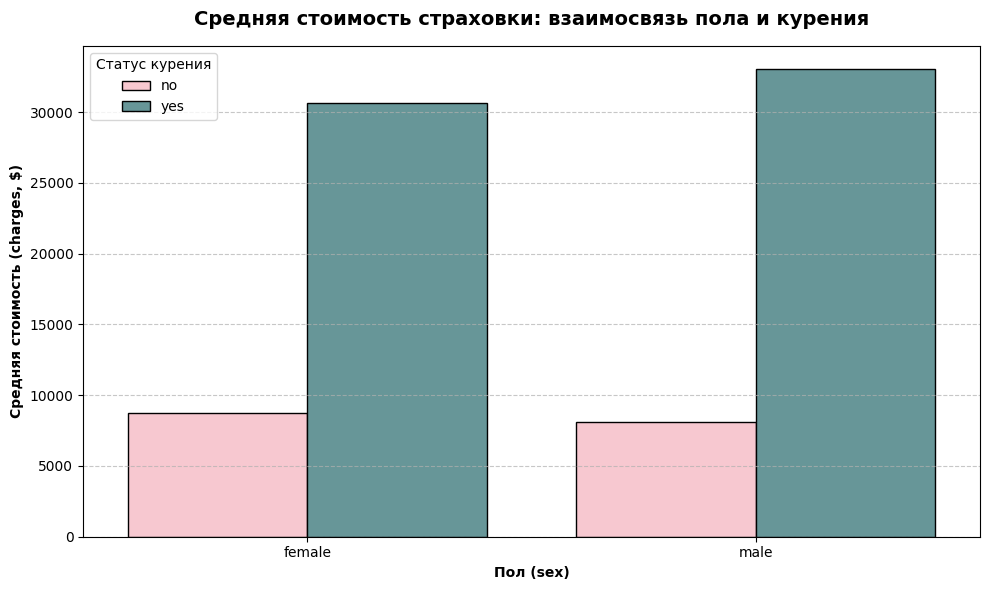

In [ ]:
# Визуализируем

plt.figure(figsize = (10, 6))

sns.barplot(
    x = 'sex',
    y = 'avg_charges',
    hue = 'smoker',
    data = cross_stats,
    palette = {'no': 'pink', 'yes': 'cadetblue'},
    edgecolor = 'black'
)

plt.title('Средняя стоимость страховки: взаимосвязь пола и курения', fontsize = 14, fontweight = 'bold', pad = 15)
plt.xlabel('Пол (sex)', fontweight = 'bold')
plt.ylabel('Средняя стоимость (charges, $)', fontweight = 'bold')

plt.legend(title = 'Статус курения')

plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)

plt.tight_layout()

plt.show()

## Вывод:
Пол сам по себе не является фактором с сильным влиянием, в отличие от того, является ли пациент курильщиком или нет;


# Шаг 2: Обогащение данных и расширенный анализ

## Посмотрим, какие признаки можно создать на основе имеющихся:

    • age_group (age) — скомпануем пациентов в возрастные группы для удобства анализа;
    • bmi_category (bmi) — скомпануем пациентов по категориям в соответствии с медицинским стандартом для этого показателя;
    • high_risk (age + smoker) — выделим группу максимального риска с наибольшими затратами по страховке;
    • cost_marker (charges) — флаг-признак для ABC-анализа;
    • is_parent (children) — флаг-признак для ABC-анализа;

In [ ]:
# Добавим новые признаки в датафрейм

# Категории по индексу массы тела

def get_bmi_category(bmi):
    if bmi < 18.5:
        return 'Недовес'
    elif 18.5 < bmi <= 25:
        return 'Норма'
    elif 25 < bmi <= 30:
        return 'Избыточный вес'
    elif bmi > 30:
        return 'Ожирение'

med_df['bmi_category'] = med_df['bmi'].apply(get_bmi_category)

# Категории по возрасту

def get_age_group(age):
    if age <= 30:
        return 'Молодые (18-30)'
    elif age <= 50:
        return 'Средний возраст (31-50)'
    else:
        return 'Зрелый возраст (51-64)'

med_df['age_group'] = med_df['age'].apply(get_age_group)

# Флаг по наличию детей

med_df['is_parent'] = (med_df['children'] > 0).astype(int)

# Флаг принадлежности к группе высокого риска
med_df['high_risk_flag'] = (
    (med_df['smoker'] == 'yes') &
    (med_df['age_group'] == 'Зрелый возраст (51-64)')
).astype(int)

med_df

,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group,is_parent,high_risk_flag
0,19,female,27.900,0,yes,southwest,16884.92400,Избыточный вес,Молодые (18-30),0,0
1,18,male,33.770,1,no,southeast,1725.55230,Ожирение,Молодые (18-30),1,0
2,28,male,33.000,3,no,southeast,4449.46200,Ожирение,Молодые (18-30),1,0
3,33,male,22.705,0,no,northwest,21984.47061,Норма,Средний возраст (31-50),0,0
4,32,male,28.880,0,no,northwest,3866.85520,Избыточный вес,Средний возраст (31-50),0,0
...,...,...,...,...,...,...,...,...,...,...,...
1332,50,male,30.970,3,no,northwest,10600.54830,Ожирение,Средний возраст (31-50),1,0
1333,18,female,31.920,0,no,northeast,2205.98080,Ожирение,Молодые (18-30),0,0
1334,18,female,36.850,0,no,southeast,1629.83350,Ожирение,Молодые (18-30),0,0
1335,21,female,25.800,0,no,southwest,2007.94500,Избыточный вес,Молодые (18-30),0,0


## ABC-анализ

In [ ]:
# Сортируем от самой большой суммы к самой маленькой

abc_df = med_df[['charges']].copy().sort_values('charges', ascending = False).reset_index(drop = True)


# Считаем накопительный процент (чтобы разделить на группы)

total_charges = abc_df['charges'].sum()
abc_df['cumulative_charges'] = abc_df['charges'].cumsum()
abc_df['cumulative_percent'] = (abc_df['cumulative_charges'] / total_charges) * 100

# Присваиваем категории

def assign_abc_group(percent):
    if percent <= 80:
        return 'A'
    elif percent <= 95:
        return 'B'
    else:
        return 'C'

abc_df['abc_group'] = abc_df['cumulative_percent'].apply(assign_abc_group)

# Собираем в таблицу

abc_summary = abc_df.groupby('abc_group').agg(
    patients_count = ('charges', 'count'),
    total_charges = ('charges', 'sum'),
    avg_charges = ('charges', 'mean'),
    median_charges = ('charges', 'median')
).round(2)

abc_summary['patients_percent'] = (abc_summary['patients_count'] / len(abc_df) * 100).round(1)
abc_summary['charges_percent'] = (abc_summary['total_charges'] / total_charges * 100).round(1)

abc_summary



,patients_count,total_charges,avg_charges,median_charges,patients_percent,charges_percent
abc_group,,,,,,
A,641,14196572.28,22147.54,17560.38,47.9,80.0
B,376,2668811.03,7097.90,7145.98,28.1,15.0
C,320,888802.11,2777.51,2662.11,23.9,5.0


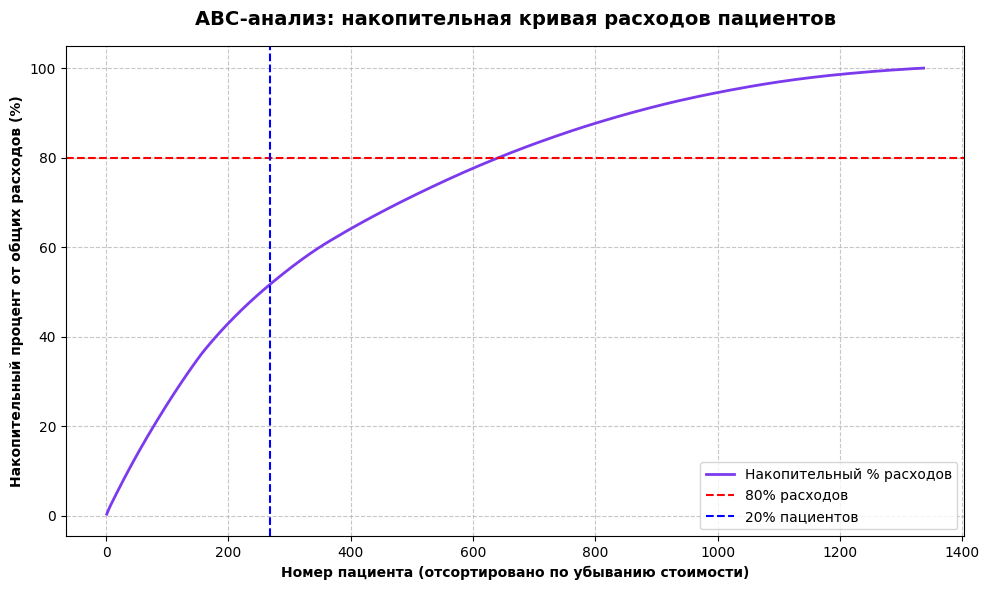

In [ ]:
# Визуализируем

plt.figure(figsize = (10, 6))

plt.plot(
    range(1, len(abc_df) + 1),
    abc_df['cumulative_percent'],
    color = '#7C3AED',
    linewidth = 2,
    label = 'Накопительный % расходов'
)

plt.axhline(y = 80, color = 'red', linestyle = '--', linewidth = 1.5, label = '80% расходов')
plt.axvline(x = len(abc_df) * 0.2, color = 'blue', linestyle = '--', linewidth = 1.5, label = '20% пациентов')

plt.title('ABC-анализ: накопительная кривая расходов пациентов', fontsize = 14, fontweight = 'bold', pad = 15)
plt.xlabel('Номер пациента (отсортировано по убыванию стоимости)', fontweight = 'bold')
plt.ylabel('Накопительный процент от общих расходов (%)', fontweight='bold')

plt.legend()

plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

In [ ]:
# Выявим "Портрет клиента с высоким финансовым риском" для страховой компании


med_df_abc = med_df.copy()

abc_with_index = med_df[['charges']].copy()
abc_with_index = abc_with_index.sort_values('charges', ascending = False)
abc_with_index['abc_group'] = abc_df['abc_group'].values
abc_with_index = abc_with_index.sort_index()

med_df_abc['abc_group'] = abc_with_index['abc_group']

abc_profile = med_df_abc.groupby('abc_group').agg(
    avg_age = ('age', 'mean'),
    avg_bmi = ('bmi', 'mean'),
    smokers_percent = ('smoker', lambda x: (x == 'yes').mean() * 100),
    high_risk_percent = ('high_risk_flag', 'mean'),
    is_parent_percent = ('is_parent', 'mean'),
    avg_charges = ('charges', 'mean')
).round(2)

abc_profile


,avg_age,avg_bmi,smokers_percent,high_risk_percent,is_parent_percent,avg_charges
abc_group,,,,,,
A,46.28,31.13,42.75,0.1,0.55,22147.54
B,40.49,30.55,0.00,0.0,0.78,7097.90
C,23.58,29.87,0.00,0.0,0.37,2777.51


In [ ]:
smokers_by_group = med_df_abc.groupby('abc_group')['smoker'].value_counts().unstack(fill_value=0)
smokers_percent_by_group = abc_profile['smokers_percent']

smokers_dict = smokers_by_group.copy()
smokers_dict['percent_yes'] = smokers_percent_by_group

smokers_dict

smoker,no,yes,percent_yes
abc_group,,,
A,367,274,42.75
B,376,0,0.00
C,320,0,0.00


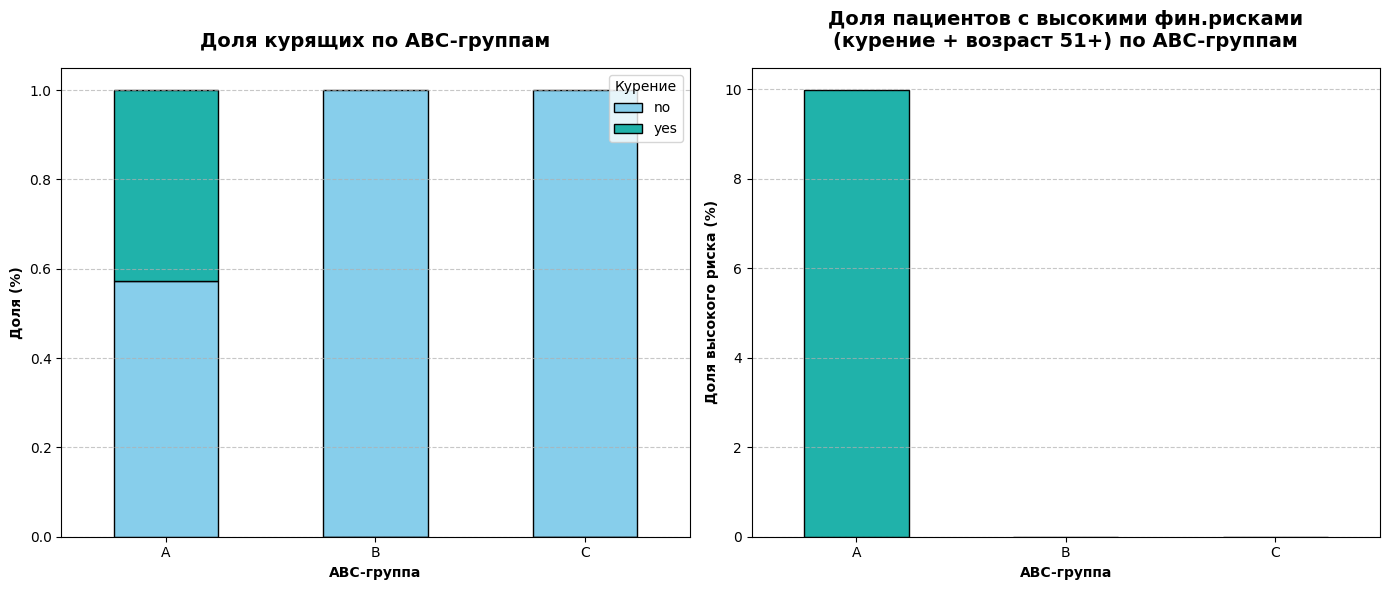

In [ ]:
# Визуализируем

fig, axes = plt.subplots(1, 2, figsize = (14, 6))

# График 1: Доля курящих

smoker_by_abc = med_df_abc.groupby('abc_group')['smoker'].value_counts(normalize = True).unstack().fillna(0)

smoker_by_abc.plot(
    kind = 'bar',
    stacked = True,
    ax = axes[0],
    color =['#87CEEB', '#20B2AA'],
    edgecolor = 'black'
)

axes[0].set_title('Доля курящих по ABC-группам', fontsize = 14, fontweight = 'bold', pad = 15)
axes[0].set_xlabel('ABC-группа', fontweight = 'bold')
axes[0].set_ylabel('Доля (%)', fontweight = 'bold')

axes[0].legend(title='Курение')

axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation = 0)

axes[0].grid(axis = 'y', linestyle = '--', alpha = 0.7)

# График 2: Доля высокого риска

high_risk_by_abc = med_df_abc.groupby('abc_group')['high_risk_flag'].mean() * 100

high_risk_by_abc.plot(
    kind = 'bar',
    ax = axes[1],
    color = '#20B2AA',
    edgecolor = 'black'
)

axes[1].set_title('Доля пациентов с высокими фин.рисками\n(курение + возраст 51+) по ABC-группам',
                  fontsize = 14, fontweight = 'bold', pad = 15)
axes[1].set_xlabel('ABC-группа', fontweight = 'bold')
axes[1].set_ylabel('Доля высокого риска (%)', fontweight = 'bold')

axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation = 0)

axes[1].grid(axis = 'y', linestyle = '--', alpha = 0.7)

plt.tight_layout()

plt.show()

## Выводы по ABC-анализу:

  **Фактически:**

    • Группа A составляет 641 пациент (47.9% от всех) и генерирует ~80% всех расходов.
    • Все 274 курящих пациента (100%) находятся в группе A.
    • Внутри группы A курящие составляют 42.7%, тогда как в группах B и C курящих нет вообще (0%).
    
  **Интерпретация:**

    • Курение является критическим фактором, который автоматически переводит пациента в группу высоких расходов (A).
    • Даже если курящий пациент молод и имеет нормальный BMI, его расходы всё равно попадают в топ-20% из-за мультипликативного эффекта курения на стоимость страховки.
    • Группы B и C состоят исключительно из некурящих пациентов, различающихся только по возрасту и другим факторам.
    
 **Гипотеза:**

    • Для прогнозирования стоимости страховки статус курения (smoker) является бинарным переключателем: если пациент курит, он с вероятностью ~100% попадает в группу высоких расходов (A).
    • Это объясняет, почему в EDA мы видели чёткое разделение на "слои" на scatter plot — курение создаёт отдельный кластер высоких расходов независимо от других признаков.




## XYZ-анализ

**Ограничение:**

Поскольку временные показатели в датасете отсутствуют, провести XYZ-анализ не представляется возможным. Поскольку датасет является настоящим, синтез дополнительных данных в данном случае будет нарушением аналитической этики.

## RMF-анализ

**Ограничение:**

Поскольку в используемом датасете имеются данные только для компоненты M, проведение полноценного содержательного RFM-анализа не представляется возможным.

# Шаг 3: Визуализация в BI-инструментах

In [ ]:
med_df_abc.info()

export_filename = 'insurance_analyzed_for_bi.csv'

med_df_abc.to_csv(export_filename, index=False, encoding='utf-8-sig')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1337 non-null   int64  
 1   sex             1337 non-null   object 
 2   bmi             1337 non-null   float64
 3   children        1337 non-null   int64  
 4   smoker          1337 non-null   object 
 5   region          1337 non-null   object 
 6   charges         1337 non-null   float64
 7   bmi_category    1336 non-null   object 
 8   age_group       1337 non-null   object 
 9   is_parent       1337 non-null   int64  
 10  high_risk_flag  1337 non-null   int64  
 11  abc_group       1337 non-null   object 
dtypes: float64(2), int64(4), object(6)
memory usage: 125.5+ KB


## Интерактивный дашборд в Yandex DataLens

Дашборд доступен по ссылке:  
[Открыть дашборд](https://datalens.yandex.cloud/moj14putvrm5?share_link=public)

**Что представлено:**
- KPI: количество клиентов, средняя и медианная стоимость, доля курящих
- Распределение пациентов по ABC-группам
- Зависимость стоимости от BMI (по полу)
- Взаимосвязь возраста и стоимости (по статусу курения)
- Фильтры: пол, статус курения, возрастная группа, категория BMI

# Шаг 4: Машинное обучение

In [ ]:
# Подгрузим библиотеки

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor


## Линейная регрессия VS Случайный лес

In [ ]:
# Линейная регрессия

df_ml = med_df_abc.drop(columns = [
    'abc_group',
    'cumulative_percent',
    'cumulative_charges'
], errors='ignore')

X = df_ml.drop(columns = ['charges'])
y = df_ml['charges']

numeric_features = ['age', 'bmi', 'children', 'is_parent', 'high_risk_flag']
categorical_features = ['sex', 'smoker', 'region', 'age_group', 'bmi_category']

preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


pipeline.fit(X_train, y_train)


y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Метрики качества Линейной регрессии:")
print(f"MAE (Средняя абсолютная ошибка): {mae:.2f} $")
print(f"RMSE (Корень из среднеквадратичной ошибки): {rmse:.2f} $")
print(f"R² (Коэффициент детерминации): {r2:.3f}")
print("-" * 60)
print("Интерпретация для бизнеса:")
print(f"В среднем модель ошибается в прогнозе стоимости на {mae:.0f} $.")
print(f"Модель объясняет {r2*100:.1f}% вариативности стоимости страховки.")

Метрики качества Линейной регрессии:
MAE (Средняя абсолютная ошибка): 4398.27 $
RMSE (Корень из среднеквадратичной ошибки): 6070.10 $
R² (Коэффициент детерминации): 0.799
------------------------------------------------------------
Интерпретация для бизнеса:
В среднем модель ошибается в прогнозе стоимости на 4398 $.
Модель объясняет 79.9% вариативности стоимости страховки.


In [ ]:
# Случайный лес

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators = 100,
        max_depth = 10,
        random_state = 42,
        n_jobs = -1
    ))
])


pipeline_rf.fit(X_train, y_train)


y_pred_rf = pipeline_rf.predict(X_test)


mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Метрики качества Случайного леса:")
print(f"MAE (Средняя абсолютная ошибка): {mae_rf:.2f} $")
print(f"RMSE (Корень из среднеквадратичной ошибки): {rmse_rf:.2f} $")
print(f"R² (Коэффициент детерминации): {r2_rf:.3f}")
print("-" * 60)
print("Интерпретация для бизнеса:")
print(f"В среднем модель ошибается в прогнозе стоимости на {mae_rf:.0f} $.")
print(f"Модель объясняет {r2_rf*100:.1f}% вариативности стоимости страховки.")


Метрики качества Случайного леса:
MAE (Средняя абсолютная ошибка): 2574.75 $
RMSE (Корень из среднеквадратичной ошибки): 4604.14 $
R² (Коэффициент детерминации): 0.885
------------------------------------------------------------
Интерпретация для бизнеса:
В среднем модель ошибается в прогнозе стоимости на 2575 $.
Модель объясняет 88.5% вариативности стоимости страховки.


In [ ]:
# Сравнение моделей:

comparison = pd.DataFrame({
    'Модель': ['Линейная регрессия', 'Random Forest'],
    'MAE ($)': [mae, mae_rf],
    'RMSE ($)': [rmse, rmse_rf],
    'R²': [r2, r2_rf],
    'Улучшение R² (%)': [0.0, round((r2_rf - r2) / r2 * 100, 1)]
})

print("📊 Сравнение моделей машинного обучения:")
print(comparison.to_string(index=False))
print("-" * 60)


if r2_rf > r2:
    improvement = (r2_rf - r2) * 100
    print(f"✅ Random Forest показал лучший результат: R² выше на {improvement:.1f}%")
    print(f"   Средняя ошибка прогноза (MAE) уменьшилась на {mae - mae_rf:.0f} $")
else:
    print("ℹ️ Линейная регрессия показала результат не хуже или лучше сложной модели.")

print("-" * 60)
print("💡 Вывод для бизнеса:")
if mae_rf < mae * 0.95:  # если ошибка уменьшилась более чем на 5%
    print("Сложная модель (Random Forest) дает заметное улучшение точности прогноза.")
    print("Её стоит использовать, если критически важна минимизация ошибки.")
else:
    print("Простая модель (Линейная регрессия) работает почти так же хорошо, как сложная.")
    print("Random Forest дает лишь незначительное улучшение, но сложнее в интерпретации.")

📊 Сравнение моделей машинного обучения:
            Модель     MAE ($)    RMSE ($)       R²  Улучшение R² (%)
Линейная регрессия 4398.268327 6070.103043 0.799483               0.0
     Random Forest 2574.753113 4604.135535 0.884640              10.7
------------------------------------------------------------
✅ Random Forest показал лучший результат: R² выше на 8.5%
   Средняя ошибка прогноза (MAE) уменьшилась на 1824 $
------------------------------------------------------------
💡 Вывод для бизнеса:
Сложная модель (Random Forest) дает заметное улучшение точности прогноза.
Её стоит использовать, если критически важна минимизация ошибки.


In [ ]:
# Выявление логики модели

import shap
from sklearn.inspection import PartialDependenceDisplay

rf_model = pipeline_rf.named_steps['regressor']


explainer = shap.TreeExplainer(rf_model)

X_test_processed = pipeline_rf.named_steps['preprocessor'].transform(X_test)


cat_encoder = pipeline_rf.named_steps['preprocessor'].named_transformers_['cat']
cat_features_encoded = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_features_encoded)

shap_values = explainer.shap_values(X_test_processed)


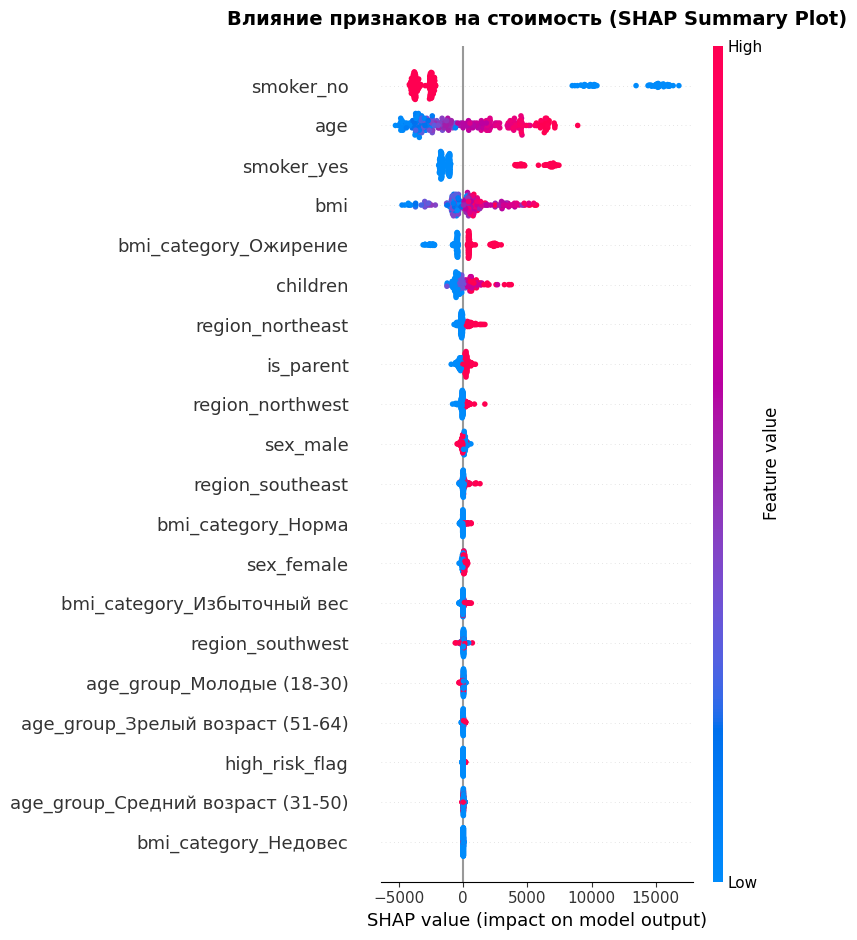

In [ ]:
#  Визуализируем (график важности признаков)

plt.figure(figsize = (10, 6))

shap.summary_plot(shap_values, X_test_processed, feature_names = all_feature_names, show = False)

plt.title("Влияние признаков на стоимость (SHAP Summary Plot)", fontsize = 14, fontweight = 'bold', pad = 15)

plt.tight_layout()

plt.show()


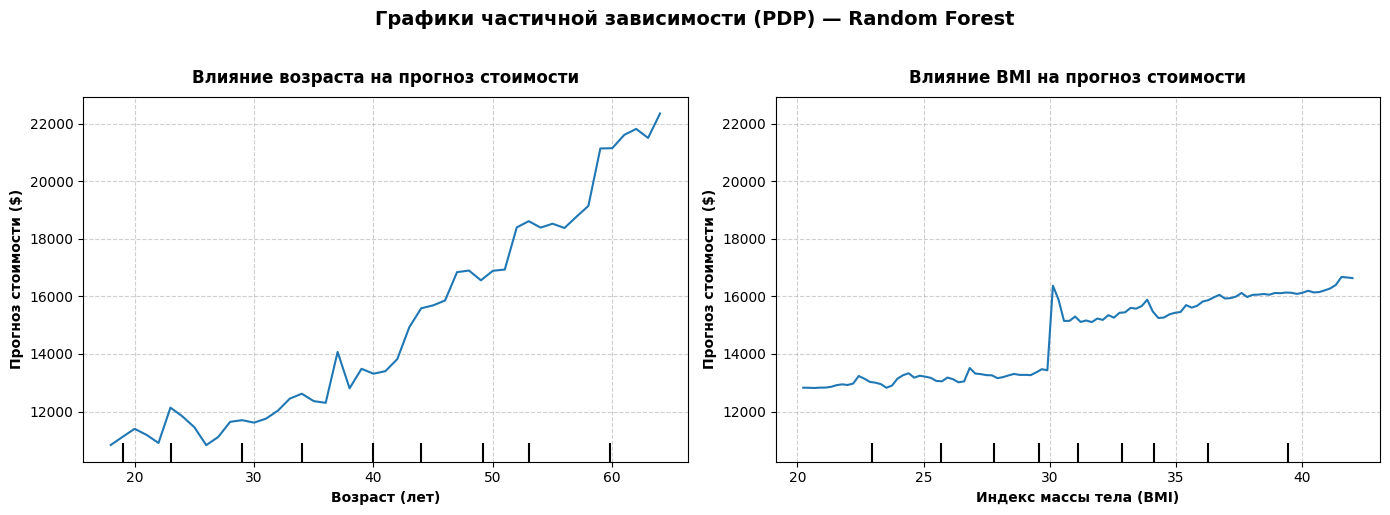

In [ ]:
# Визуализируем (график частной зависимости)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

features_to_plot = ['age', 'bmi']

display = PartialDependenceDisplay.from_estimator(
    pipeline_rf,
    X_test,
    features = features_to_plot,
    kind = 'average',
    ax = axes
)

axes[0].set_title('Влияние возраста на прогноз стоимости', fontsize = 12, fontweight = 'bold', pad = 10)
axes[0].set_xlabel('Возраст (лет)', fontweight = 'bold')
axes[0].set_ylabel('Прогноз стоимости ($)', fontweight = 'bold')
axes[0].grid(True, linestyle = '--', alpha = 0.6)

axes[1].set_title('Влияние BMI на прогноз стоимости', fontsize = 12, fontweight = 'bold', pad = 10)
axes[1].set_xlabel('Индекс массы тела (BMI)', fontweight = 'bold')
axes[1].set_ylabel('Прогноз стоимости ($)', fontweight = 'bold')
axes[1].grid(True, linestyle = '--', alpha = 0.6)

fig.suptitle('Графики частичной зависимости (PDP) — Random Forest',
             fontsize = 14, fontweight = 'bold', y = 1.02)

plt.tight_layout()

plt.show()

# Итоги

Была проведена комплексная оценка факторов, влияющих на стоимость медицинских страховок (`charges`), с целью выявления ключевых драйверов расходов и построения прогнозной модели.

### Ключевые факты из данных
- **Статус курения** является абсолютным лидером среди факторов стоимости. 100% пациентов-курильщиков (274 чел., ~20.5% выборки) попали в группу **A** ABC-анализа, которая генерирует ~80% всех расходов.
- **Возраст и BMI** сами по себе имеют слабую линейную связь со стоимостью, но модель машинного обучения (Random Forest) выявила нелинейные пороги: резкий рост прогнозируемой стоимости начинается при BMI ≈ 30 (граница ожирения по ВОЗ) и возрасте ≈ 50 лет.
- **Пол пациента** не является самостоятельным драйвером стоимости. Наблюдаемая разница в средних чеках полностью объясняется разной долей курящих среди мужчин и женщин.
- **Моделирование**: Модель Random Forest (R² = 0.885) превзошла базовую линейную регрессию (R² = 0.799), снизив среднюю абсолютную ошибку (MAE) с $4,398 до $2574.75.
- **SHAP-анализ** подтвердил, что признаки `smoker_yes`/`smoker_no` и `age` вносят наибольший вклад в прогноз модели.

### Интерпретация результатов
- Страховые расходы распределены крайне неравномерно (принцип Парето). Небольшая группа пациентов с комбинацией факторов риска (курение + старший возраст) формирует основную финансовую нагрузку.
- Превосходство Random Forest над линейной регрессией объясняется способностью алгоритма автоматически улавливать нелинейные взаимодействия признаков (например, синергию возраста и курения), которые линейная модель сглаживает.
- Выявленные пороги (BMI=30, Age=50) имеют четкое медицинское обоснование, что повышает доверие к интерпретируемости модели.

### Ограничения проведенного анализа
1. **Отсутствие временной оси**: Датасет является кросс-секционным (единовременный срез). Это делает невозможным применение классических RFM- и XYZ-анализов, требующих истории транзакций или наблюдений во времени.
2. **Причинно-следственная связь**: Выявленные корреляции и важность признаков в ML-модели указывают на статистическую связь, но не доказывают строгую причинно-следственную зависимость без учета скрытых факторов (например, региональных особенностей медицины).
3. **Качество данных**: Анализ опирается на самоотчетные данные пациентов (например, BMI и статус курения), которые могут содержать неточности.

### Предложения
 **Сбор данных**: Инициировать сбор дополнительных признаков (наличие хронических заболеваний, частота обращений к врачу) для повышения точности прогноза.